# CUDA-MODE session 4 (ch 4 + 5 of the book)

Notebook by Thomas Viehmann, based on Jeremy Howard's notebook from lecture 3

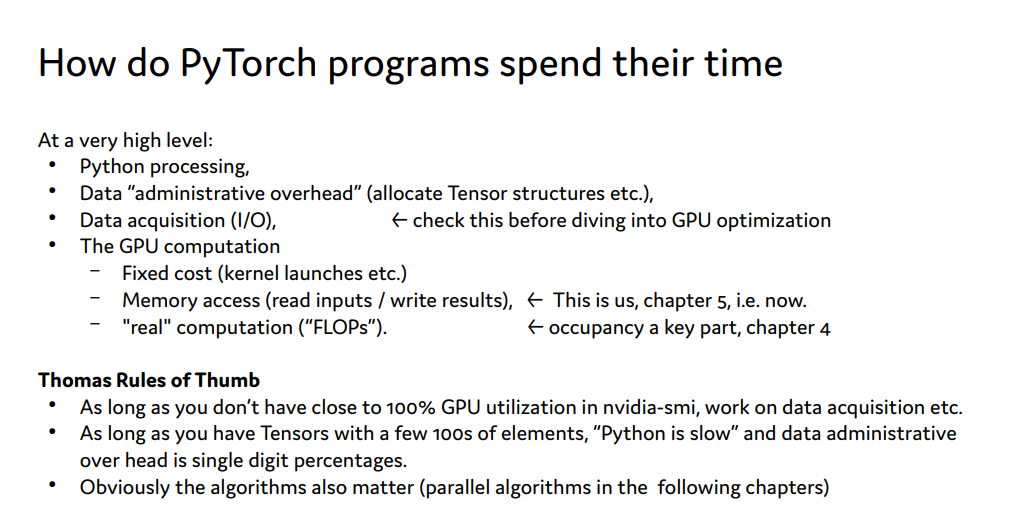

In [1]:
!pip install ninja



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import torch
import torch.utils.cpp_extension
import os
os.environ["CC"] = "gcc-12"
os.environ["CXX"] = "g++-12"

In [19]:

# based on Jeremy's Lecture 3 notebook
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}
'''

cuda_src = cuda_begin + r'''
__global__ void rgb_to_grayscale_kernel(unsigned char* out, unsigned char* in, int n) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    if (i >= n) return;
    out[i] = 0.2989f*in[i] + 0.5870f*in[i+n] + 0.1140f*in[i+2*n];  // fix with f found by Andreas...
}

torch::Tensor rgb_to_grayscale_out(torch::Tensor output, const torch::Tensor& input) {
    CHECK_INPUT(input);
    int h = input.size(1);
    int w = input.size(2);
    TORCH_CHECK((h == output.size(0)) || (w == output.size(1)) || (output.device() == input.device())
                || (output.scalar_type() == input.scalar_type()));
    int threads = 256;
    rgb_to_grayscale_kernel<<<cdiv(w*h,threads), threads>>>(
        output.data_ptr<unsigned char>(), input.data_ptr<unsigned char>(), w*h);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}

torch::Tensor rgb_to_grayscale(const torch::Tensor& input) {
    CHECK_INPUT(input);
    int h = input.size(1);
    int w = input.size(2);
    auto output = torch::empty({h,w}, input.options());
    rgb_to_grayscale_out(output, input);
    return output;
}
'''

cpp_src = """
torch::Tensor rgb_to_grayscale(const torch::Tensor& input);
torch::Tensor rgb_to_grayscale_out(torch::Tensor outpuit, const torch::Tensor& input);
"""



module = torch.utils.cpp_extension.load_inline(
    "test_ext", cpp_src, cuda_src, 
    functions=['rgb_to_grayscale', 'rgb_to_grayscale_out'], extra_cuda_cflags=['--ptxas-options=-v'], verbose=True)



n = 2048
t = torch.randint(0, 256, (3, n, n), dtype=torch.uint8, device="cuda")
out = module.rgb_to_grayscale(t); torch.cuda.synchronize()

import time
t0 = time.perf_counter_ns()
for i in range(10_000):
    module.rgb_to_grayscale_out(out, t)
torch.cuda.synchronize()
t1 = time.perf_counter_ns()

print((t1-t0) / 10_000 / 1_000, "µs") 


with torch.profiler.profile() as prof:
    for i in range(10_000):
        module.rgb_to_grayscale_out(out, t)
        torch.cuda.synchronize()

print(prof.key_averages().table())


229.6654794 µs
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       cudaLaunchKernel         4.45%      47.151ms         4.48%      47.411ms       4.741us       0.000us         0.00%       0.000us       0.000us         10000  
                                           Unrecognized         0.02%     260.326us         0.02%     260.326us     260.326us       0.000us         0.00%       0.000us       0.000us           

# Approximate gelu as a fusion example

In [8]:
import torch
# as per the pytorch doc, implemented manually
def gelu(x):
    return 0.5 * x * (1+ torch.tanh((2/torch.pi)**0.5 * (x+0.044715 * x**3)))

x = torch.randn(1024, 1024, device="cuda") 

In [9]:
gelu(x) - torch.nn.functional.gelu(x, approximate='tanh')

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')

In [10]:
%timeit gelu(x); torch.cuda.synchronize()
%timeit torch.nn.functional.gelu(x, approximate='tanh'); torch.cuda.synchronize()

981 μs ± 16.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
136 μs ± 1.71 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [11]:
with torch.profiler.profile() as prof:
    %timeit -n 1000 gelu(x)

print(prof.key_averages().table())

/home/mohamed/tf-env/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


920 μs ± 72.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::mul         5.29%     266.161ms        54.14%        2.725s      97.330us        2.660s        49.89%        5.031s     179.696us         28000  
                                           Unrecognized         0.42%      21.228ms         0.42%      21.228ms       2.654ms     834.

## Kind of slow. Why?

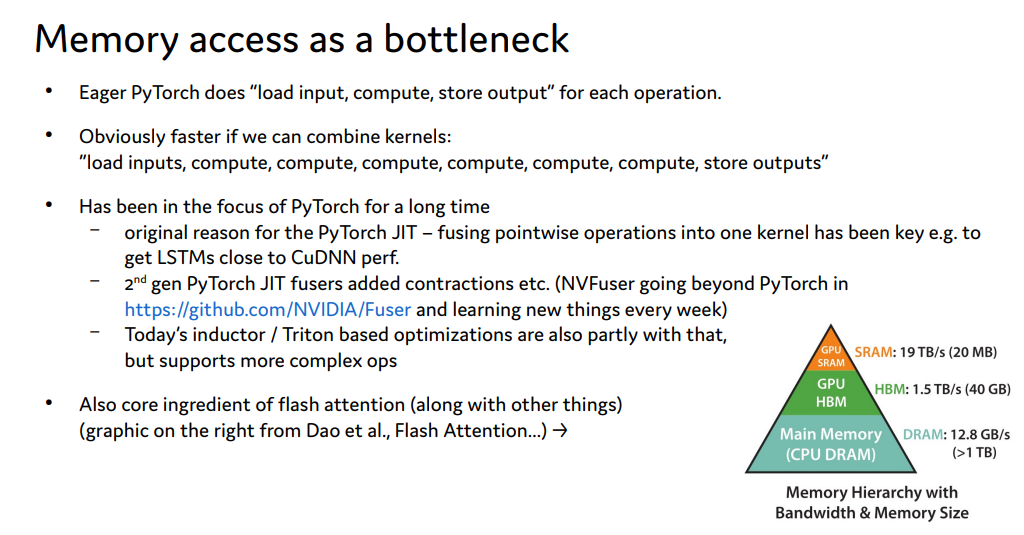

In [3]:

# based on Jeremy's Lecture 3 notebook
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}
'''

cuda_src = cuda_begin + r'''
__global__ void my_gelu_kernel(float* out, float* inp, int n) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    if (i >= n) return;
    float x = inp[i];
    out[i] = 0.5f * x * (1.0f+ tanhf(sqrtf(2.0f/3.141592653589793f) * (x+0.044715f * (x*x*x))));
}

torch::Tensor my_gelu_out(torch::Tensor output, const torch::Tensor& inp) {
    CHECK_INPUT(inp);
    int n = inp.numel();
    TORCH_CHECK((output.sizes() == inp.sizes())  || (output.device() == inp.device())
                || (output.scalar_type() == inp.scalar_type()));
    int threads = 256;
    my_gelu_kernel<<<cdiv(n, threads), threads>>>(
        output.data_ptr<float>(), inp.data_ptr<float>(), n);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}

torch::Tensor my_gelu(const torch::Tensor& inp) {
    CHECK_INPUT(inp);
    auto output = torch::empty_like(inp);
    my_gelu_out(output, inp);
    return output;
}
'''

cpp_src = """
torch::Tensor my_gelu(const torch::Tensor& inp);
torch::Tensor my_gelu_out(torch::Tensor output, const torch::Tensor& inp);
"""

print("Compiling...")
gelu_module_opt = torch.utils.cpp_extension.load_inline(
    "test_ext_gelu", cpp_src, cuda_src, 
    functions=['my_gelu', 'my_gelu_out'], extra_cuda_cflags=['--ptxas-options=-v'], verbose=True)

print("Loaded!")

Compiling...
[1/3] g++-12 -MMD -MF main.o.d -DTORCH_EXTENSION_NAME=test_ext_gelu -DTORCH_API_INCLUDE_EXTENSION_H -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda-12.3/include -isystem /usr/include/python3.12 -fPIC -std=c++17 -c /home/mohamed/.cache/torch_extensions/py312_cu126/test_ext_gelu/main.cpp -o main.o 
[2/3] /usr/local/cuda-12.3/bin/nvcc --generate-dependencies-with-compile --dependency-output cuda.cuda.o.d -ccbin gcc-12 -DTORCH_EXTENSION_NAME=test_ext_gelu -DTORCH_API_INCLUDE_EXTENSION_H -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda-12.3/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_

In [15]:
x = torch.randn(1024, 1024, device="cuda") 
(gelu_module_opt.my_gelu(x) - gelu(x)).abs().max()


tensor(2.3842e-07, device='cuda:0')

In [16]:
%timeit gelu_module_opt.my_gelu(x); torch.cuda.synchronize()
%timeit torch.nn.functional.gelu(x, approximate='tanh'); torch.cuda.synchronize()366

131 μs ± 4.43 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
134 μs ± 1.28 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


# Empty kernel to measure launch latency


In [1]:
import torch
import torch.utils.cpp_extension
import os
os.environ["CC"] = "gcc-12"
os.environ["CXX"] = "g++-12"

In [2]:

# based on Jeremy's Lecture 3 notebook
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}    //this is ceiling division, i.e. cdiv(5,2) = 3
'''


cuda_src = cuda_begin + r'''
__global__ void my_empty_kernel(float* out, float* inp, int n) {
}

torch::Tensor my_empty_out(torch::Tensor output, const torch::Tensor& inp) {
    CHECK_INPUT(inp);
    int n = inp.numel();
    TORCH_CHECK((output.sizes() == inp.sizes())  || (output.device() == inp.device())
                || (output.scalar_type() == inp.scalar_type()));
    int threads = 256;
    my_empty_kernel<<<cdiv(n, threads), threads>>>(
        output.data_ptr<float>(), inp.data_ptr<float>(), n);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}

torch::Tensor my_empty(const torch::Tensor& inp) {
    CHECK_INPUT(inp);
    auto output = torch::empty_like(inp);
    my_empty_out(output, inp);
    return output;
}
'''

cpp_src = """
torch::Tensor my_empty(const torch::Tensor& inp);
torch::Tensor my_empty_out(torch::Tensor output, const torch::Tensor& inp);
"""

empty_module = torch.utils.cpp_extension.load_inline(
    "test_ext_empty", cpp_src, cuda_src, 
    functions=['my_empty', 'my_empty_out'], extra_cuda_cflags=['--ptxas-options=-v'], verbose=True)

[1/3] g++-12 -MMD -MF main.o.d -DTORCH_EXTENSION_NAME=test_ext_empty -DTORCH_API_INCLUDE_EXTENSION_H -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda-12.3/include -isystem /usr/include/python3.12 -fPIC -std=c++17 -c /home/mohamed/.cache/torch_extensions/py312_cu126/test_ext_empty/main.cpp -o main.o 
[2/3] /usr/local/cuda-12.3/bin/nvcc --generate-dependencies-with-compile --dependency-output cuda.cuda.o.d -ccbin gcc-12 -DTORCH_EXTENSION_NAME=test_ext_empty -DTORCH_API_INCLUDE_EXTENSION_H -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include -isystem /home/mohamed/tf-env/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda-12.3/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS_

In [4]:
x = torch.randn(1024, 1024, device="cuda") 
%timeit empty_module.my_empty_out(x, x); torch.cuda.synchronize()

with torch.profiler.profile() as prof:
    for i in range(10_000):
        empty_module.my_empty_out(x, x)
        torch.cuda.synchronize()
print(prof.key_averages().table())

41 μs ± 3.94 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


/home/mohamed/tf-env/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


----------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                    Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
----------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                        cudaLaunchKernel        22.03%      69.250ms        23.13%      72.684ms       7.268us       0.000us         0.00%       0.000us       0.000us         10000  
                            Unrecognized         1.09%       3.434ms         1.09%       3.434ms       3.434ms       0.000us         0.00%       0.000us       0.000us             1  
    my_empty_kernel(float*, float*, int)         0.00%       0.000us         0.00%  

## Matmul

In [5]:
cuda_src = cuda_begin + r'''
__global__ void simple_matmul_k(float* m, float* n, float* out, int h, int w, int k) {
    int r = blockIdx.y*blockDim.y + threadIdx.y;
    int c = blockIdx.x*blockDim.x + threadIdx.x;

    if (r>=h || c>=w) return;
    float o = 0;
    for (int i = 0; i<k; ++i) o += m[r*k+i] * n[i*w+c];
    out[r*w+c] = o;
}

torch::Tensor simple_matmul(const torch::Tensor& m, const torch::Tensor& n) {
    CHECK_INPUT(m); CHECK_INPUT(n);
    int h = m.size(0);
    int w = n.size(1);
    int k = m.size(1);
    TORCH_CHECK(k==n.size(0), "Size mismatch!");
    auto output = torch::zeros({h, w}, m.options());

    dim3 tpb(16,16);
    dim3 blocks(cdiv(w, tpb.x), cdiv(h, tpb.y));
    simple_matmul_k<<<blocks, tpb>>>(
        m.data_ptr<float>(), n.data_ptr<float>(), output.data_ptr<float>(), h, w, k);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}
'''

cpp_src = """
torch::Tensor simple_matmul(const torch::Tensor& m, const torch::Tensor& n);
"""

simple_matmul_module = torch.utils.cpp_extension.load_inline(
    "test_ext_simple_matmul", cpp_src, cuda_src, 
    functions=['simple_matmul'], extra_cuda_cflags=['--ptxas-options=-v'], verbose=True)

ninja: no work to do.


In [6]:
a = torch.randn(1024, 1024, device="cuda")
b = torch.randn(1024, 1024, device="cuda")
%timeit simple_matmul_module.simple_matmul(a, b)

(simple_matmul_module.simple_matmul(a, b) - a@b).abs().max()

6.48 ms ± 88.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


tensor(0.0002, device='cuda:0')

## Tiled matmul

In [2]:
# based on Jeremy's Lecture 3 notebook
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}    //this is ceiling division, i.e. cdiv(5,2) = 3
'''


cuda_src = cuda_begin + r"""
constexpr int TILE_SIZE = 16;

__global__ void tiled_matmul_kernel(float* out, float* M, float* N, int h, int w, int k) {
  __shared__ float M_tile[TILE_SIZE][TILE_SIZE];
  __shared__ float N_tile[TILE_SIZE][TILE_SIZE];
  
  // idxes into tile
  int ir = threadIdx.y;
  int ic = threadIdx.x;
  
  int r = blockIdx.y * blockDim.y + threadIdx.y;
  int c = blockIdx.x * blockDim.x + threadIdx.x;

  // note: cannot just exit if we want to do padding!
  
  float res = 0.0f;
  for (int K_tileidx = 0; K_tileidx < (k + TILE_SIZE -1) / TILE_SIZE; K_tileidx++) {
    // note how threadIdx.x is the fastes moving bit --> coalesced memory access
    M_tile[ir][ic] = (((r < h) && (K_tileidx * TILE_SIZE + ic < k)) ? M[r * k + K_tileidx * TILE_SIZE + ic] : 0.f);
    N_tile[ir][ic] = ((((K_tileidx * TILE_SIZE + ir) < k) && (c < w)) ? N[(K_tileidx * TILE_SIZE + ir) * w + c] : 0.f);
    //M_tile[ir][ic] = M[r * k + K_tileidx * TILE_SIZE + ic];
    //N_tile[ir][ic] = N[(K_tileidx * TILE_SIZE + ir) * w + c];
    __syncthreads();
    for (int idx = 0; idx < TILE_SIZE; idx++) {
       res += M_tile[ir][idx] * N_tile[idx][ic];
    }
    __syncthreads(); // important! (why?)
  }
  if ((r < h) && (c < w)) {
    out[r * w + c] = res;
  }
}

torch::Tensor tiled_matmul(const torch::Tensor& m, const torch::Tensor& n) {
    CHECK_INPUT(m); CHECK_INPUT(n);
    int h = m.size(0);
    int w = n.size(1);
    int k = m.size(1);
    TORCH_CHECK(k==n.size(0), "Size mismatch");
    //TORCH_CHECK((k % TILE_SIZE == 0) && (h % TILE_SIZE == 0) && (w % TILE_SIZE == 0), "Padding not done");
    auto output = torch::empty({h, w}, m.options());

    dim3 tpb(TILE_SIZE, TILE_SIZE);
    dim3 blocks(cdiv(w, tpb.x), cdiv(h, tpb.y));
    tiled_matmul_kernel<<<blocks, tpb>>>(
        output.data_ptr<float>(), m.data_ptr<float>(), n.data_ptr<float>(), h, w, k);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}

"""
cpp_src = """
torch::Tensor tiled_matmul(const torch::Tensor& m, const torch::Tensor& n);
"""

tiled_matmul_module = torch.utils.cpp_extension.load_inline(
    "test_ext_tiled_matmul", cpp_src, cuda_src, 
    functions=['tiled_matmul'], extra_cuda_cflags=['--ptxas-options=-v'], verbose=True)

ninja: no work to do.


In [4]:

a = torch.randn(1024, 1024, device="cuda")
b = torch.randn(1024, 1024, device="cuda")
%timeit tiled_matmul_module.tiled_matmul(a, b)

4.46 ms ± 135 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [8]:
aa = torch.randn(500, 200, device="cuda")
bb = torch.randn(200, 1000, device="cuda")


(tiled_matmul_module.tiled_matmul(aa, bb) - aa@bb).abs().max()


tensor(3.8147e-05, device='cuda:0')

# Occupancy?

- shared memory: 64k/2k -> 32
- threads: 1536/256 -> 6

$\rightarrow$ we could afford larger tiles